# Détection de faux billets

L'objectif est d'explorer les dimensions géométriques de billets, d'y rechercher une
structure (ACP, classification non supervisée) puis de construire un modèle estimant la
probabilité qu'un billet soit authentique.

- **Mission 0** : description des données, analyses univariées et bivariées, tests statistiques.
- **Mission 1** : analyse en composantes principales (éboulis, cercle des corrélations, plans factoriels).
- **Mission 2** : classification non supervisée (CAH et K-means) et comparaison avec la vraie nature des billets.
- **Mission 3** : modèle de classification supervisée, choix du seuil de décision, prédiction des nouveaux billets.

Le notebook s'exécute de haut en bas (*Kernel → Restart & Run All*) et tous les tirages
aléatoires sont fixés par `RANDOM_STATE`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.cluster.hierarchy import fcluster, linkage
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    adjusted_rand_score,
    brier_score_loss,
    classification_report,
    make_scorer,
    recall_score,
    silhouette_score,
)
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
    learning_curve,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree

import fonctions_analyse as fa
import modele

RANDOM_STATE = modele.RANDOM_STATE
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 72

## Chargement des données

In [2]:
X, y = modele.charger_donnees_apprentissage()
classes = fa.libeller_classes(y)
df = X.assign(is_genuine=y)
df.head()

,diagonal,height_left,height_right,margin_low,margin_up,length,is_genuine
0,171.81,104.86,104.95,4.52,2.89,112.83,1
1,171.67,103.74,103.70,4.01,2.87,113.29,1
2,171.83,103.76,103.76,4.40,2.88,113.84,1
3,171.80,103.78,103.65,3.73,3.12,113.63,1
4,172.05,103.70,103.75,5.04,2.27,113.55,1


Le rapport d'exploration automatique (`rapport_exploration_donnees.html`) n'est plus
versionné : il se génère à la demande avec `python generer_rapport.py`.

# Mission 0 : description des données

## Analyse de forme

In [3]:
synthese, resume = fa.synthese_donnees(df)
print(resume)
synthese

{'lignes': 170, 'colonnes': 7, 'doublons': 0, 'lignes_avec_outlier': 5}


,type,valeurs_uniques,manquantes,taux_manquantes_%,outliers,taux_outliers_%
diagonal,float64,88,0,0.0,3,1.76
height_left,float64,91,0,0.0,0,0.00
height_right,float64,96,0,0.0,1,0.59
margin_low,float64,123,0,0.0,0,0.00
margin_up,float64,81,0,0.0,1,0.59
length,float64,129,0,0.0,0,0.00
is_genuine,int64,2,0,0.0,0,0.00


- 170 billets, 6 variables quantitatives et la cible `is_genuine`.
- Aucune valeur manquante, aucun doublon.
- Quelques valeurs atypiques (règle de Tukey) ; elles sont plausibles et conservées.

In [4]:
X.describe().round(2)

,diagonal,height_left,height_right,margin_low,margin_up,length
count,170.00,170.00,170.00,170.00,170.00,170.00
mean,171.94,104.07,103.93,4.61,3.17,112.57
std,0.31,0.30,0.33,0.70,0.24,0.92
min,171.04,103.23,103.14,3.54,2.27,109.97
25%,171.73,103.84,103.69,4.05,3.01,111.85
50%,171.94,104.06,103.95,4.45,3.17,112.84
75%,172.14,104.29,104.17,5.13,3.33,113.29
max,173.01,104.86,104.95,6.28,3.68,113.98


## Répartition de la cible

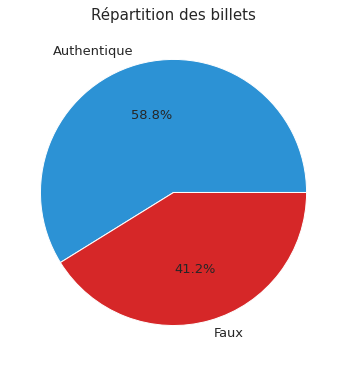

classe
Authentique    0.588
Faux           0.412
Name: proportion, dtype: float64

In [5]:
fa.graphique_repartition(classes, "Répartition des billets")
plt.show()
classes.value_counts(normalize=True).round(3)

Les classes sont légèrement déséquilibrées (≈ 59 % d'authentiques). Toutes les
découpes des données seront donc **stratifiées**.

## Distributions par classe

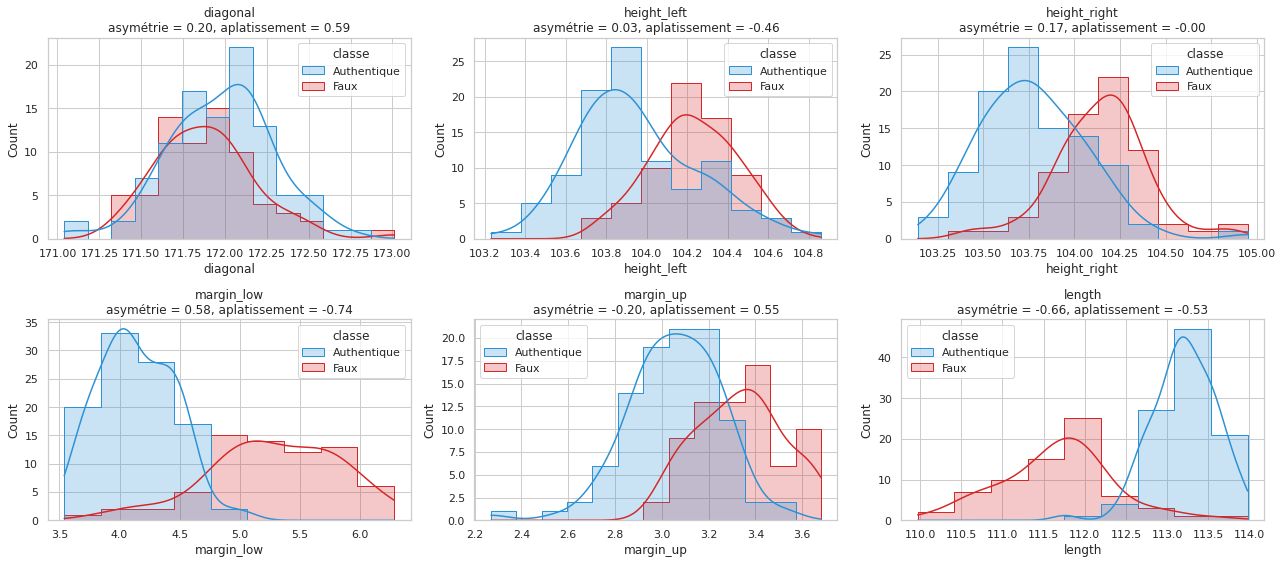

In [6]:
fa.histogrammes_par_classe(X, classes)
plt.show()

`margin_low`, `length`, `margin_up` et, dans une moindre mesure, les hauteurs séparent
nettement les deux classes. `diagonal` se superpose presque entièrement.

## Relations entre variables

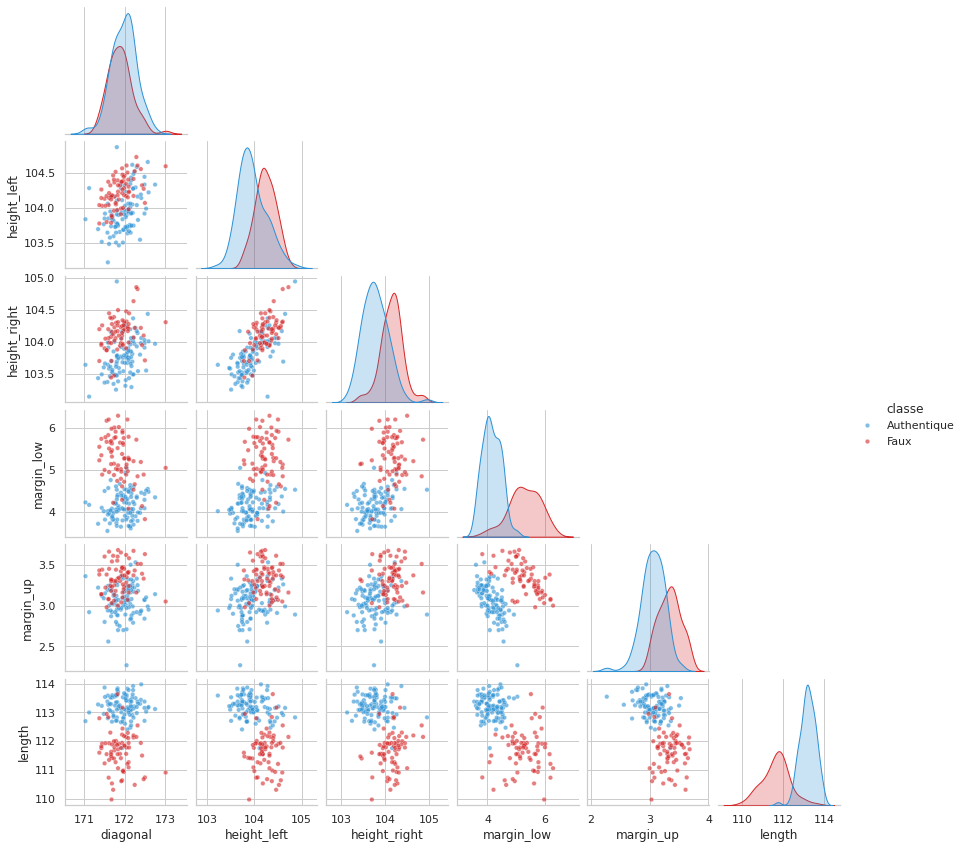

In [7]:
sns.pairplot(X.assign(classe=classes), hue="classe", palette=fa.COULEURS_CLASSES,
             corner=True, height=2, plot_kws={"alpha": 0.6, "s": 20})
plt.show()

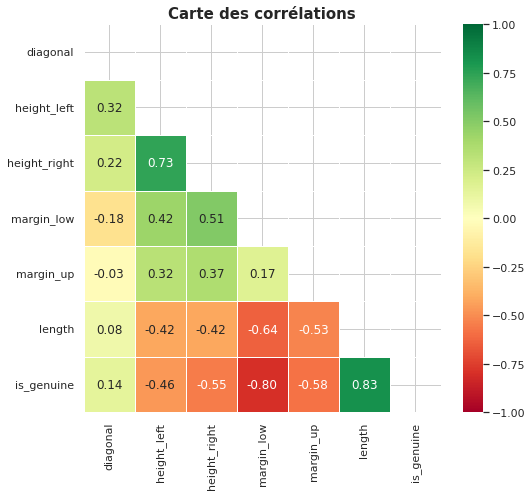

In [8]:
fa.carte_correlations(df)
plt.show()

`margin_low` (corrélation −0,80 avec la cible) et `length` sont les variables les plus liées
à l'authenticité. Les deux hauteurs sont corrélées entre elles (0,73).

## Tests statistiques

### Normalité (D'Agostino-Pearson)

H0 : la variable suit une loi normale.

In [9]:
fa.tests_normalite(X).round(4)

,statistique,p_value,normalite_rejetee
variable,,,
diagonal,3.3195,0.1902,False
height_left,2.2229,0.3291,False
height_right,0.8692,0.6475,False
margin_low,18.3829,0.0001,True
margin_up,3.2153,0.2004,False
length,14.4240,0.0007,True


La normalité est rejetée uniquement pour `margin_low` et `length`. Ce sont justement les
variables les plus discriminantes : leur distribution est un **mélange** de deux populations
(vrais et faux billets). C'est pourquoi la
comparaison des classes combine un test paramétrique et un test non paramétrique.

### Comparaison authentiques / faux

- Test t de **Welch** : ne suppose pas l'égalité des variances et utilise tous les billets
  (pas de sous-échantillonnage aléatoire).
- Test de **Mann-Whitney** : ne suppose pas la normalité.
- Six variables testées : les p-values sont ajustées par la méthode de **Holm**.
- Le **d de Cohen** mesure l'ampleur de la différence (0,8 = effet fort).

In [10]:
comparaison = fa.comparer_classes(X, y)
comparaison.style.format({
    "moyenne_authentiques": "{:.2f}", "moyenne_faux": "{:.2f}", "d_cohen": "{:.2f}",
    "p_welch": "{:.1e}", "p_mann_whitney": "{:.1e}",
    "p_welch_holm": "{:.1e}", "p_mann_whitney_holm": "{:.1e}",
})

,moyenne_authentiques,moyenne_faux,d_cohen,p_welch,p_mann_whitney,p_welch_holm,p_mann_whitney_holm,difference_significative
variable,,,,,,,,
diagonal,171.98,171.89,0.28,6.9e-02,2.0e-02,6.9e-02,2.0e-02,False
height_left,103.95,104.23,-1.08,2.7e-11,2.8e-10,5.4e-11,5.5e-10,True
height_right,103.78,104.15,-1.35,2.3e-15,3.1e-14,6.8e-15,9.4e-14,True
margin_low,4.14,5.28,-2.57,3.5e-29,4.9e-24,1.8e-28,2.4e-23,True
margin_up,3.06,3.33,-1.46,6.8e-17,1.1e-14,2.7e-16,4.2e-14,True
length,113.21,111.66,2.82,9.4e-32,3.6e-25,5.6e-31,2.1e-24,True


Une p-value supérieure à 5 % ne prouve pas l'absence d'effet : elle indique seulement que
l'échantillon ne permet pas de conclure. Le d de Cohen permet de hiérarchiser les variables :
`margin_low` et `length` ont les effets les plus forts, `diagonal` le plus faible.

# Mission 1 : analyse en composantes principales

Les variables sont centrées-réduites avant l'ACP, car elles n'ont pas la même échelle.

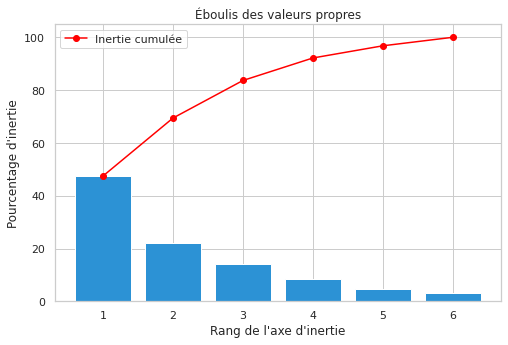

,inertie_%,inertie_cumulee_%
F1,47.4,47.4
F2,22.0,69.4
F3,14.2,83.6
F4,8.5,92.2
F5,4.6,96.8
F6,3.2,100.0


In [11]:
X_centre_reduit = StandardScaler().fit_transform(X)
pca = PCA(random_state=RANDOM_STATE).fit(X_centre_reduit)
X_projete = pca.transform(X_centre_reduit)

fa.eboulis_valeurs_propres(pca)
plt.show()
pd.DataFrame({
    "inertie_%": pca.explained_variance_ratio_ * 100,
    "inertie_cumulee_%": pca.explained_variance_ratio_.cumsum() * 100,
}, index=[f"F{i + 1}" for i in range(pca.n_components_)]).round(1)

Les deux premiers axes expliquent ≈ 69 % de l'inertie, les trois premiers ≈ 84 %.
On étudie les plans F1-F2 et F3-F4.

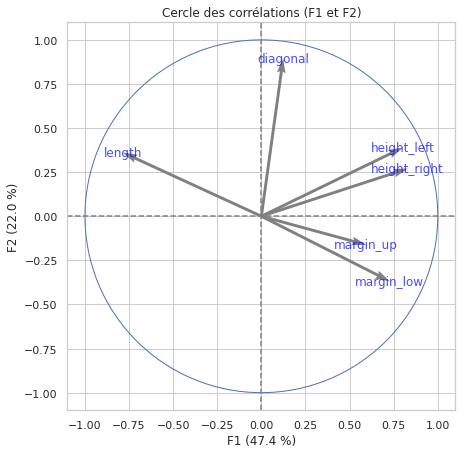

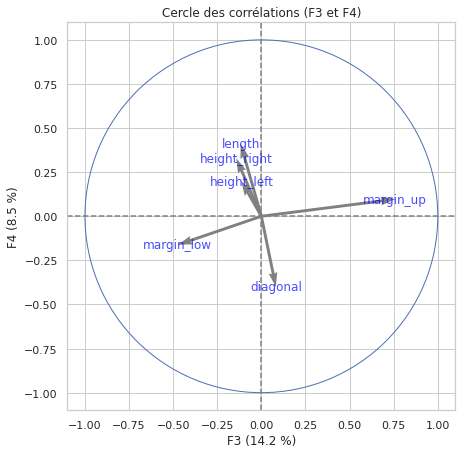

In [12]:
fa.cercle_correlations(pca, X_centre_reduit, X.columns, axes=(0, 1))
plt.show()
fa.cercle_correlations(pca, X_centre_reduit, X.columns, axes=(2, 3))
plt.show()

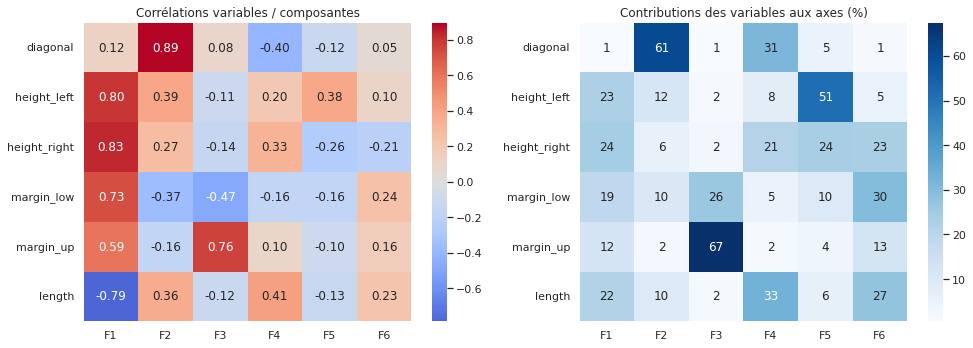

In [13]:
correlations = pd.DataFrame(
    fa.correlations_composantes(pca, X_centre_reduit),
    index=X.columns, columns=[f"F{i + 1}" for i in range(pca.n_components_)],
)
contributions = pd.DataFrame(
    pca.components_.T ** 2 * 100,
    index=X.columns, columns=correlations.columns,
)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(correlations, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[0])
axes[0].set_title("Corrélations variables / composantes")
sns.heatmap(contributions, annot=True, fmt=".0f", cmap="Blues", ax=axes[1])
axes[1].set_title("Contributions des variables aux axes (%)")
plt.tight_layout()
plt.show()

- **F1** oppose `length` aux marges et aux hauteurs : c'est l'axe « taille du billet » qui
  distingue les faux (plus courts, marges plus grandes).
- **F2** est porté essentiellement par `diagonal`.
- **F3** est dominé par `margin_up`.

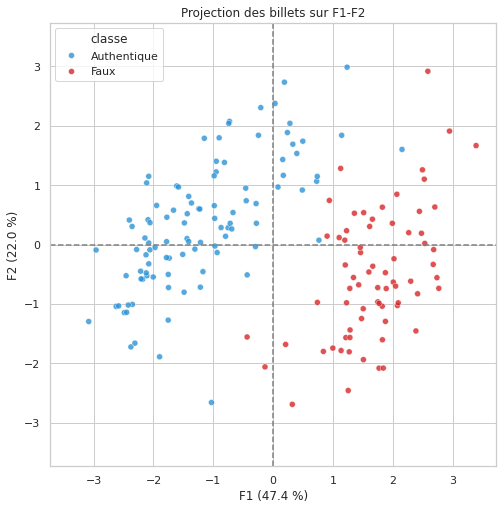

In [14]:
fa.plan_factoriel(X_projete, pca, groupes=classes, palette=fa.COULEURS_CLASSES,
                  titre="Projection des billets sur F1-F2")
plt.show()

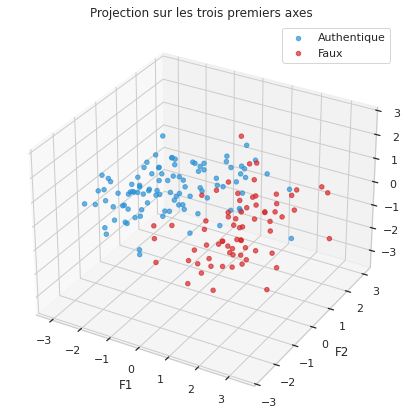

In [15]:
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(projection="3d")
for classe, couleur in fa.COULEURS_CLASSES.items():
    masque = (classes == classe).to_numpy()
    ax.scatter(*X_projete[masque, :3].T, label=classe, color=couleur, alpha=0.7)
ax.set_xlabel("F1")
ax.set_ylabel("F2")
ax.set_zlabel("F3")
ax.set_title("Projection sur les trois premiers axes")
ax.legend()
plt.show()

Sur le premier plan factoriel, les faux billets se regroupent du côté des F1 positifs :
F1 suffit presque à séparer les deux classes.

# Mission 2 : classification non supervisée

La cible n'est **jamais** utilisée pour construire les clusters ; elle sert uniquement à
évaluer, après coup, si la structure trouvée correspond à la nature des billets.

## Classification ascendante hiérarchique (Ward)

Toutes les composantes sont conservées : la CAH sur les projections est donc identique à une
CAH sur les données centrées-réduites.

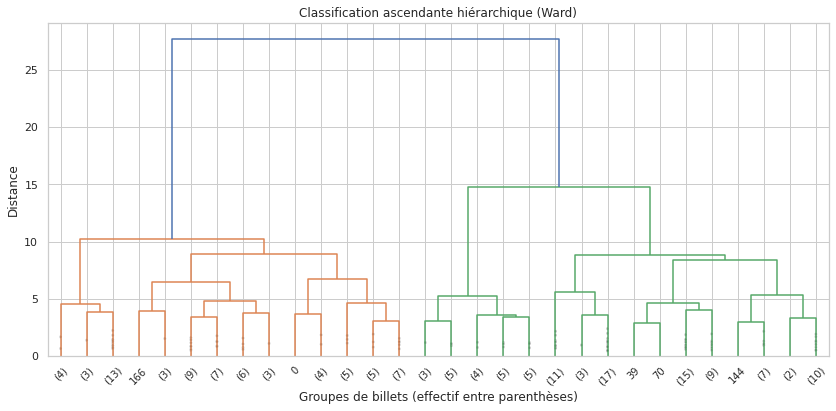

In [16]:
Z = linkage(X_centre_reduit, method="ward")
fa.graphique_dendrogramme(Z, nb_feuilles=30)
plt.show()

In [17]:
clusters_cah = fcluster(Z, t=2, criterion="maxclust")
pd.crosstab(pd.Series(clusters_cah, name="cluster CAH"), classes)

classe,Authentique,Faux
cluster CAH,,
1,2,69
2,98,1


## K-means : choix du nombre de clusters

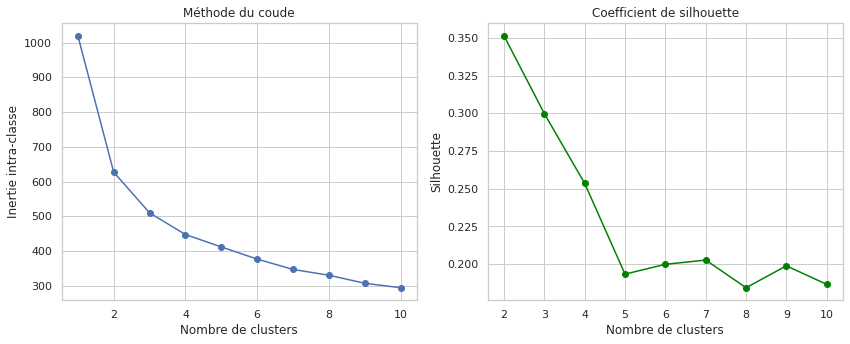

In [18]:
nb_clusters = range(1, 11)
inerties, silhouettes = [], []
for k in nb_clusters:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_centre_reduit)
    inerties.append(km.inertia_)
    if k > 1:  # la silhouette n'est pas définie pour un seul cluster
        silhouettes.append(silhouette_score(X_centre_reduit, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(nb_clusters, inerties, marker="o")
axes[0].set(title="Méthode du coude", xlabel="Nombre de clusters", ylabel="Inertie intra-classe")
axes[1].plot(nb_clusters[1:], silhouettes, marker="o", color="green")
axes[1].set(title="Coefficient de silhouette", xlabel="Nombre de clusters", ylabel="Silhouette")
plt.show()

Le coude le plus net se situe à **2 clusters**, où le coefficient de silhouette est aussi
maximal : on retient 2 clusters, ce qui correspond au nombre de classes attendu.

In [19]:
kmeans = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE).fit(X_centre_reduit)
clusters_kmeans = kmeans.labels_
pd.crosstab(pd.Series(clusters_kmeans, name="cluster K-means"), classes)

classe,Authentique,Faux
cluster K-means,,
0,8,69
1,92,1


In [20]:
resultats_clustering = {}
for nom, clusters in {"CAH (Ward)": clusters_cah, "K-means": clusters_kmeans}.items():
    correspondance = fa.correspondance_clusters(clusters, y)
    classe_predite = pd.Series(clusters).map(correspondance).to_numpy()
    resultats_clustering[nom] = {
        "taux_accord_%": 100 * np.mean(classe_predite == classes.to_numpy()),
        "indice_rand_ajuste": adjusted_rand_score(y, clusters),
    }
pd.DataFrame(resultats_clustering).T.round(3)

,taux_accord_%,indice_rand_ajuste
CAH (Ward),98.235,0.930
K-means,94.706,0.798


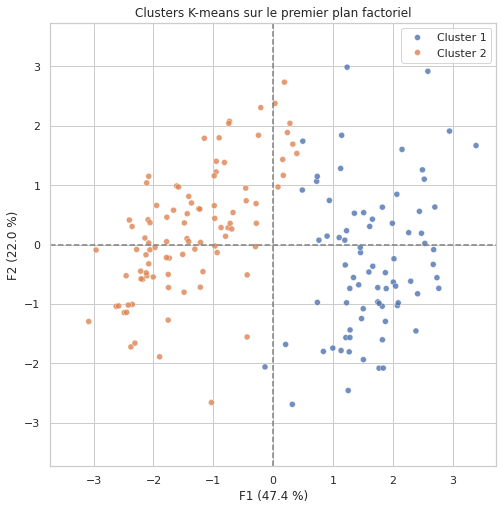

In [21]:
fa.plan_factoriel(X_projete, pca, groupes=[f"Cluster {c + 1}" for c in clusters_kmeans],
                  titre="Clusters K-means sur le premier plan factoriel")
plt.show()

Sans connaître la cible, les deux méthodes retrouvent l'essentiel de la séparation
vrais / faux : la CAH classe correctement ≈ 98 % des billets, K-means ≈ 95 % (K-means
cherche des groupes sphériques de tailles comparables, ce qui l'amène à rattacher quelques
billets authentiques au groupe des faux). Les deux populations forment des groupes
naturellement distincts, séparés le long de F1 ; les désaccords se situent à la frontière
entre les deux nuages.

# Mission 3 : modèle de détection

## Découpage stratifié apprentissage / test

Le jeu de test (30 %) est mis de côté et n'est utilisé **qu'une seule fois**, pour
l'évaluation finale. Les choix de modèle se font par validation croisée sur l'apprentissage.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE
)
pd.DataFrame({"apprentissage": y_train.value_counts(), "test": y_test.value_counts()})

,apprentissage,test
is_genuine,,
1,70,30
0,49,21


## Comparaison de modèles

Validation croisée stratifiée répétée (5 plis × 10 répétitions) : avec aussi peu de billets,
un seul découpage donnerait une estimation trop instable.

Métriques suivies :
- **ROC-AUC** : capacité à ordonner les billets, indépendamment du seuil ;
- **log-loss** : qualité des probabilités (plus petite = meilleure) ;
- **rappel des faux** : part des faux billets détectés, l'enjeu principal ;
- **F1**.

In [23]:
cv_repetee = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=RANDOM_STATE)
metriques = {
    "roc_auc": "roc_auc",
    "log_loss": "neg_log_loss",
    "rappel_faux": make_scorer(recall_score, pos_label=0),
    "f1": "f1",
}
candidats = {
    "Régression logistique": make_pipeline(StandardScaler(), LogisticRegression()),
    "Logistique polynomiale (degré 2)": make_pipeline(
        StandardScaler(), PolynomialFeatures(degree=2, include_bias=False),
        StandardScaler(), LogisticRegression(max_iter=5000)),
    "k plus proches voisins": make_pipeline(StandardScaler(), KNeighborsClassifier()),
    "SVM (noyau RBF)": make_pipeline(StandardScaler(), SVC(random_state=RANDOM_STATE)),
    "Forêt aléatoire": RandomForestClassifier(random_state=RANDOM_STATE),
}

lignes = {}
for nom, estimateur in candidats.items():
    scores = cross_validate(estimateur, X_train, y_train, cv=cv_repetee,
                            scoring={k: v for k, v in metriques.items()
                                     if not (k == "log_loss" and nom.startswith("SVM"))})
    lignes[nom] = {
        f"{m} (moy ± é-t)": f"{abs(valeurs.mean()):.3f} ± {valeurs.std():.3f}"
        for m in metriques if (valeurs := scores.get("test_" + m)) is not None
    }
pd.DataFrame(lignes).T

,roc_auc (moy ± é-t),log_loss (moy ± é-t),rappel_faux (moy ± é-t),f1 (moy ± é-t)
Régression logistique,0.999 ± 0.002,0.058 ± 0.029,0.970 ± 0.047,0.982 ± 0.024
Logistique polynomiale (degré 2),0.999 ± 0.003,0.060 ± 0.039,0.976 ± 0.055,0.984 ± 0.025
k plus proches voisins,0.993 ± 0.016,0.289 ± 0.580,1.000 ± 0.000,0.993 ± 0.015
SVM (noyau RBF),0.999 ± 0.004,NaN,0.994 ± 0.024,0.991 ± 0.019
Forêt aléatoire,0.999 ± 0.003,0.095 ± 0.031,0.988 ± 0.038,0.978 ± 0.027


Tous les modèles sont excellents et leurs écarts restent dans les marges d'incertitude
(écarts-types). On retient la **régression logistique** : c'est le modèle le plus simple et
le plus interprétable, et elle fournit directement des probabilités bien calibrées.
Le modèle polynomial n'apporte pas de gain mesurable et augmente le risque de
surapprentissage (l'ancienne version, en degré 4, obtenait un score de 1,000 en validation).

## Réglage de la régularisation

La recherche porte sur la force (`C`) et le type de régularisation (`l1_ratio` : 0 = L2,
1 = L1, entre les deux = elastic-net), avec un solveur compatible avec toutes ces
combinaisons (`saga`). Le critère est la log-loss.

In [24]:
recherche = modele.optimiser_modele(X_train, y_train)
meilleur_modele = recherche.best_estimator_
print("Paramètres retenus :", {k: float(v) for k, v in recherche.best_params_.items()})
print(f"Log-loss en validation croisée : {-recherche.best_score_:.4f}")

Paramètres retenus : {'regression__C': 31.622776601683793, 'regression__l1_ratio': 1.0}
Log-loss en validation croisée : 0.0229


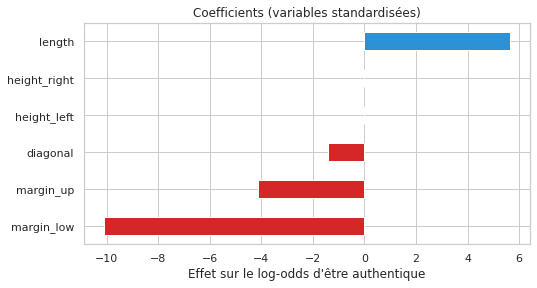

margin_low     -10.104
margin_up       -4.145
diagonal        -1.432
height_left      0.000
height_right     0.000
length           5.639
dtype: float64

In [25]:
regression = meilleur_modele.named_steps["regression"]
coefficients = pd.Series(regression.coef_[0], index=X.columns).sort_values()
coefficients.plot.barh(color=np.where(coefficients > 0, "#2C92D5", "#D62728"), figsize=(8, 4))
plt.title("Coefficients (variables standardisées)")
plt.xlabel("Effet sur le log-odds d'être authentique")
plt.show()
coefficients.round(3)

Un billet a d'autant plus de chances d'être authentique qu'il est **long** et que ses
**marges sont petites** ; `margin_low` a de loin le poids le plus fort. Les variables étant
standardisées, les coefficients sont directement comparables. La régularisation L1 retenue
met à zéro les coefficients des deux hauteurs : corrélées aux marges, elles n'apportent pas
d'information supplémentaire.

## Choix du seuil de décision

Laisser passer un faux billet est plus grave que rejeter un vrai billet (qui sera
simplement contrôlé). On fixe un coût de **5** pour un faux billet accepté et de **1** pour
un vrai billet rejeté, et on choisit le seuil qui minimise ce coût sur des probabilités
obtenues **par validation croisée** (et non sur les données ayant servi à l'entraînement).
Comme plusieurs seuils consécutifs atteignent souvent le même coût minimal, on retient le
milieu de cet intervalle.

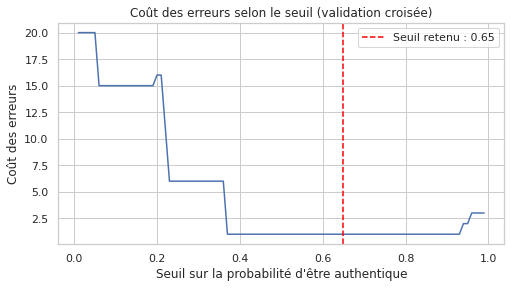

Seuil retenu : 0.65 (intervalle de coût minimal : 0.37 à 0.93)


In [26]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
proba_validation = cross_val_predict(meilleur_modele, X_train, y_train, cv=cv,
                                     method="predict_proba")[:, 1]
seuils = np.round(np.arange(0.01, 1.0, 0.01), 2)
couts = np.array([modele.cout_decision(y_train, proba_validation, s) for s in seuils])
seuil = modele.choisir_seuil(y_train, proba_validation)

plt.figure(figsize=(8, 4))
plt.plot(seuils, couts)
plt.axvline(seuil, color="red", ls="--", label=f"Seuil retenu : {seuil:.2f}")
plt.xlabel("Seuil sur la probabilité d'être authentique")
plt.ylabel("Coût des erreurs")
plt.title("Coût des erreurs selon le seuil (validation croisée)")
plt.legend()
plt.show()
print(f"Seuil retenu : {seuil:.2f} (intervalle de coût minimal : "
      f"{seuils[couts == np.min(couts)].min():.2f} à {seuils[couts == np.min(couts)].max():.2f})")

## Évaluation finale sur le jeu de test

              precision    recall  f1-score   support

        Faux      1.000     1.000     1.000        21
 Authentique      1.000     1.000     1.000        30

    accuracy                          1.000        51
   macro avg      1.000     1.000     1.000        51
weighted avg      1.000     1.000     1.000        51

Score de Brier : 0.0073


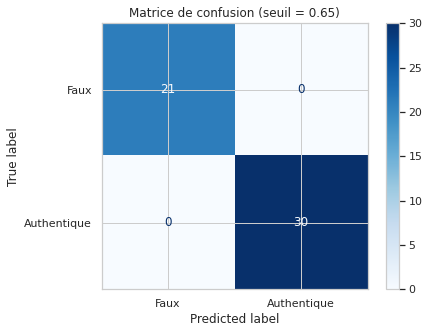

In [27]:
meilleur_modele.fit(X_train, y_train)
proba_test = meilleur_modele.predict_proba(X_test)[:, 1]
y_pred = (proba_test >= seuil).astype(int)

print(classification_report(y_test, y_pred, target_names=["Faux", "Authentique"], digits=3))
print(f"Score de Brier : {brier_score_loss(y_test, proba_test):.4f}")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Faux", "Authentique"],
                                        cmap="Blues")
plt.title(f"Matrice de confusion (seuil = {seuil:.2f})")
plt.show()

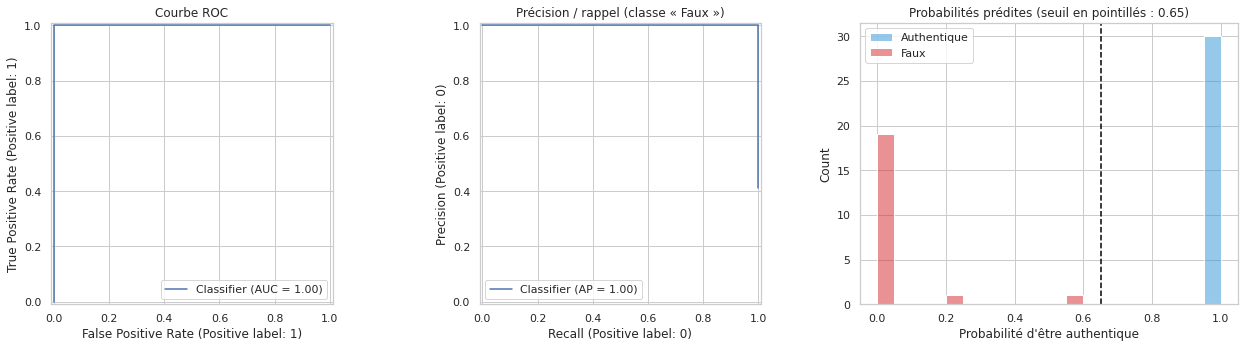

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
RocCurveDisplay.from_predictions(y_test, proba_test, ax=axes[0])
axes[0].set_title("Courbe ROC")
PrecisionRecallDisplay.from_predictions(y_test, 1 - proba_test, pos_label=0, ax=axes[1])
axes[1].set_title("Précision / rappel (classe « Faux »)")
sns.histplot(x=proba_test, hue=fa.libeller_classes(y_test).to_numpy(), bins=20,
             palette=fa.COULEURS_CLASSES, ax=axes[2])
axes[2].axvline(seuil, color="black", ls="--")
axes[2].set(title=f"Probabilités prédites (seuil en pointillés : {seuil:.2f})",
            xlabel="Probabilité d'être authentique")
plt.tight_layout()
plt.show()

Le jeu de test ne contient que 51 billets : une erreur de plus ou de moins fait varier les
métriques d'environ 2 points. Les estimations de validation croisée répétée ci-dessus sont
plus fiables pour juger du niveau de performance attendu.

## Courbe d'apprentissage

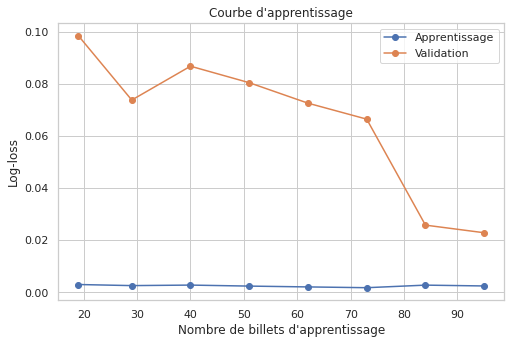

In [29]:
tailles, scores_train, scores_validation = learning_curve(
    meilleur_modele, X_train, y_train, cv=cv, scoring="neg_log_loss",
    train_sizes=np.linspace(0.2, 1.0, 8),
)
plt.figure(figsize=(8, 5))
plt.plot(tailles, -scores_train.mean(axis=1), marker="o", label="Apprentissage")
plt.plot(tailles, -scores_validation.mean(axis=1), marker="o", label="Validation")
plt.xlabel("Nombre de billets d'apprentissage")
plt.ylabel("Log-loss")
plt.title("Courbe d'apprentissage")
plt.legend()
plt.show()

Les courbes d'apprentissage et de validation se rejoignent : le modèle ne surapprend pas.

## Analyse des erreurs et des cas incertains

Pour chaque billet du test mal classé ou incertain (probabilité entre 0,1 et 0,9), on regarde
ses plus proches voisins parmi les billets d'apprentissage, dans l'espace des mesures
standardisées (la cible n'est pas utilisée pour la recherche des voisins).

In [30]:
a_examiner = (y_pred != y_test.to_numpy()) | ((proba_test > 0.1) & (proba_test < 0.9))
normalisation = StandardScaler().fit(X_train)
voisins = NearestNeighbors(n_neighbors=5).fit(normalisation.transform(X_train))

print(f"Erreurs sur le test : {np.sum(y_pred != y_test.to_numpy())}")
for identifiant, billet in X_test[a_examiner].iterrows():
    proba = proba_test[X_test.index.get_loc(identifiant)]
    print(f"\nBillet {identifiant} : réel = {classes[identifiant]}, "
          f"probabilité d'être authentique = {proba:.3f}, "
          f"prédit = {'Authentique' if proba >= seuil else 'Faux'}")
    _, indices = voisins.kneighbors(normalisation.transform(billet.to_frame().T))
    display(X_train.iloc[indices[0]].assign(classe=classes.loc[X_train.index[indices[0]]]))

Erreurs sur le test : 0

Billet 124 : réel = Faux, probabilité d'être authentique = 0.239, prédit = Faux


,diagonal,height_left,height_right,margin_low,margin_up,length,classe
138,171.65,104.32,104.38,5.65,3.24,112.30,Faux
103,172.04,104.34,104.48,4.88,3.28,112.15,Faux
105,171.99,104.18,104.20,5.26,3.23,111.83,Faux
9,172.14,104.34,104.20,4.63,3.02,112.47,Authentique
104,171.75,104.16,104.23,5.75,3.25,111.68,Faux



Billet 102 : réel = Faux, probabilité d'être authentique = 0.563, prédit = Faux


,diagonal,height_left,height_right,margin_low,margin_up,length,classe
69,171.94,104.11,104.16,4.08,3.35,111.76,Authentique
126,171.99,104.28,104.32,4.71,3.45,112.18,Faux
128,172.08,104.15,104.17,4.96,3.40,112.29,Faux
106,172.22,104.17,104.07,4.52,3.67,112.13,Faux
110,172.10,104.30,104.21,4.07,3.41,111.27,Faux


Les billets incertains sont des faux billets dont les mesures se rapprochent de celles des
vrais (leurs voisins les plus proches sont majoritairement faux, mais pas tous). Avec le seuil
par défaut de 0,5, le billet dont la probabilité dépasse 0,5 aurait été **accepté à tort** :
le seuil relevé par l'analyse des coûts permet de le rejeter.

## Illustration : arbre de décision

Un arbre peu profond donne une règle lisible et confirme le rôle central de `margin_low`
et `length`.

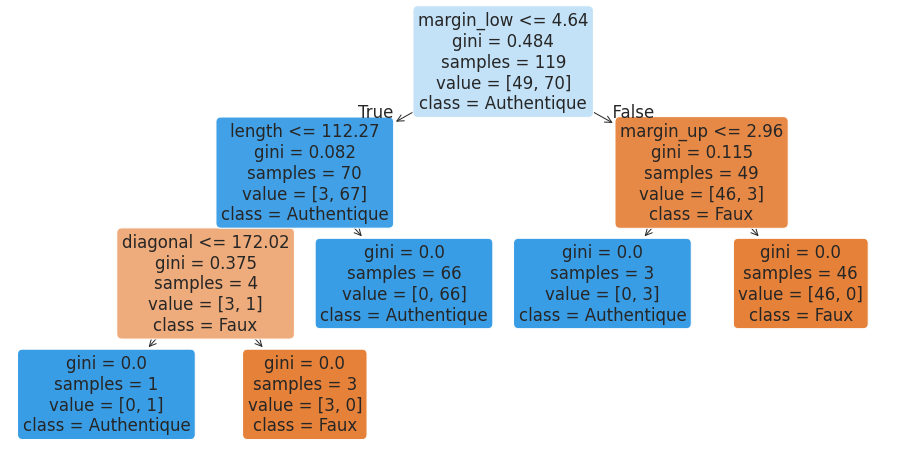

margin_low      0.803
margin_up       0.098
length          0.074
diagonal        0.026
height_left     0.000
height_right    0.000
dtype: float64

In [31]:
arbre = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE).fit(X_train, y_train)
plt.figure(figsize=(16, 8))
plot_tree(arbre, feature_names=list(X.columns), class_names=["Faux", "Authentique"],
          filled=True, rounded=True)
plt.show()
pd.Series(arbre.feature_importances_, index=X.columns).sort_values(ascending=False).round(3)

L'ordre des `class_names` suit celui des classes du modèle (`arbre.classes_` = `[0, 1]`),
c'est-à-dire Faux puis Authentique.

# Prédiction des nouveaux billets

Le modèle final est réentraîné sur **toutes** les données d'apprentissage (même procédure :
réglage de la régularisation puis choix du seuil par validation croisée), sauvegardé, puis
appliqué au fichier `donnees_a_predire.csv`. Le même traitement est disponible en ligne de
commande avec `python entrainer.py` puis `python predire.py`.

In [32]:
artefact = modele.entrainer(X, y)
chemin = modele.sauvegarder(artefact)
print(f"Modèle sauvegardé dans {chemin.relative_to(modele.DOSSIER_PROJET)}")
print("Paramètres :", artefact["parametres"], "| seuil :", artefact["seuil"])

billets_a_predire = modele.charger_donnees_a_predire()
modele.predire(artefact, billets_a_predire)

Modèle sauvegardé dans modele/modele_billets.joblib
Paramètres : {'regression__C': 3.1622776601683795, 'regression__l1_ratio': 1.0} | seuil : 0.63


,proba_authentique,prediction,statut
id,,,
A_1,0.0002,0,Faux billet
A_2,0.0000,0,Faux billet
A_3,0.0005,0,Faux billet
A_4,0.9978,1,Billet authentique
A_5,1.0000,1,Billet authentique
